In [1]:
! pip install pyresample
! pip install netCDF4

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr
from pyresample import geometry, kd_tree
import pyresample
import netCDF4 as nc
import os
import gdown
import torch
from torch.utils.data import Dataset, DataLoader
from netCDF4 import Dataset as ncDataset

In [3]:
class NetCDFDataset(Dataset):
    def __init__(self, input_dir, label_dir, file_list):
        self.input_dir = input_dir
        self.label_dir = label_dir
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]

        # paths
        x_path = os.path.join(self.input_dir, fname)
        y_path = os.path.join(self.label_dir, fname)

        # open files
        nc_x = ncDataset(x_path)
        nc_y = ncDataset(y_path)

        # input data (6, 128, 128)
        x = nc_x.variables["rs_all"][:]

        # label data (from /labeled folder)
        y = nc_y.variables["mask_all"][:]

        nc_x.close()
        nc_y.close()

        # convert to tensors only (no processing)
        x = torch.tensor(x)
        y = torch.tensor(y)

        return x, y

In [4]:

def download_and_unzip(file_id, zip_name, unzip_dir):
    """
    Downloads a Google Drive file using gdown, unzips it into a specific folder,
    and lists the extracted files.
    """
    os.makedirs(unzip_dir, exist_ok=True)

    # Build Google Drive URL
    download_url = f"https://drive.google.com/uc?id={file_id}"
    output_path = os.path.join("./", zip_name)

    print(f"Downloading {zip_name} from Google Drive...")
    gdown.download(download_url, output_path, quiet=False)

    print(f"Unzipping {zip_name} into {unzip_dir}...")
    os.system(f'unzip -o "{output_path}" -d "{unzip_dir}"')

    print(f"Files extracted in {unzip_dir}:")
    os.system(f'ls -lh "{unzip_dir}"')


download_and_unzip("1kfvR4suora_0jzHKI00nb5lAJ74rik1O", "labeled.zip", "./")

# data_brut.zip
download_and_unzip("190qpiN3hFvyNqqHT3kG2dKhRfbszd-5T", "data_brut.zip", "./")

Downloading...
From: https://drive.google.com/uc?id=1kfvR4suora_0jzHKI00nb5lAJ74rik1O
To: /content/labeled.zip
100%|██████████| 265k/265k [00:00<00:00, 28.2MB/s]


Unzipping labeled.zip into ./...
Files extracted in ./:


Downloading...
From (original): https://drive.google.com/uc?id=190qpiN3hFvyNqqHT3kG2dKhRfbszd-5T
From (redirected): https://drive.google.com/uc?id=190qpiN3hFvyNqqHT3kG2dKhRfbszd-5T&confirm=t&uuid=d01c809b-7207-4d4d-bbc2-b85e5f989108
To: /content/data_brut.zip
100%|██████████| 160M/160M [00:02<00:00, 57.5MB/s]


Unzipping data_brut.zip into ./...
Files extracted in ./:


In [5]:
### The data contains cloud coverage, so many days could be full of NaN, cleaned_file_list.txt keeps the days that have information
# Google Drive file URL
url = 'https://drive.google.com/uc?id=1Ijc6aANfFnZzYvVth7MxMhhffWpK4fuj'

# Destination path where the file will be saved
output = 'cloudless_list.txt'

# Download the file
gdown.download(url, output, quiet=False)

print(f"File downloaded as: {output}")

Downloading...
From: https://drive.google.com/uc?id=1Ijc6aANfFnZzYvVth7MxMhhffWpK4fuj
To: /content/cloudless_list.txt
100%|██████████| 12.9k/12.9k [00:00<00:00, 20.0MB/s]

File downloaded as: cloudless_list.txt


In [6]:
def normalize_with_nan(arr):
    # Exclude NaN values and normalize the array to range [0, 1]
    valid_values = arr[~np.isnan(arr)]
    normalized_values = (valid_values - np.nanmin(valid_values)) / (np.nanmax(valid_values) - np.nanmin(valid_values))

    # Create a new array with NaN values replaced by the normalized values
    normalized_arr = np.empty_like(arr)
    normalized_arr[~np.isnan(arr)] = normalized_values
    normalized_arr[np.isnan(arr)] = np.nan

    return normalized_arr

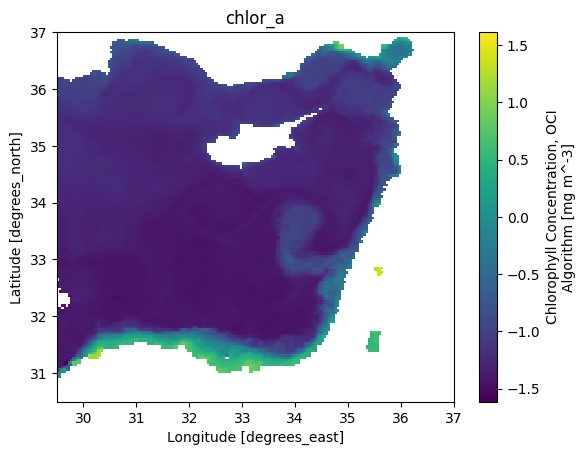

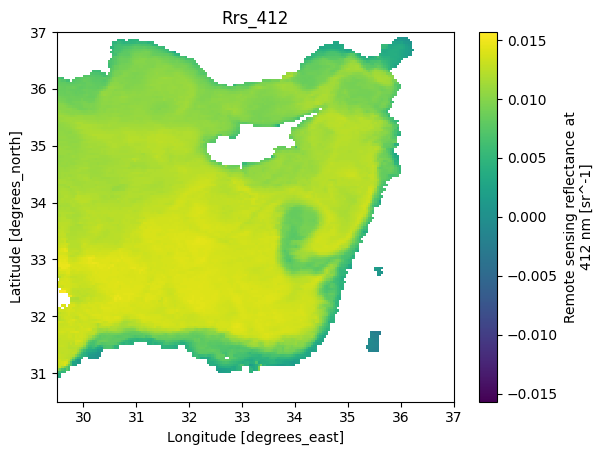

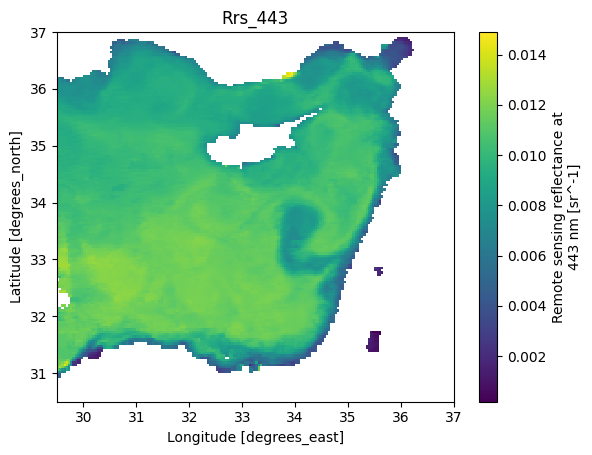

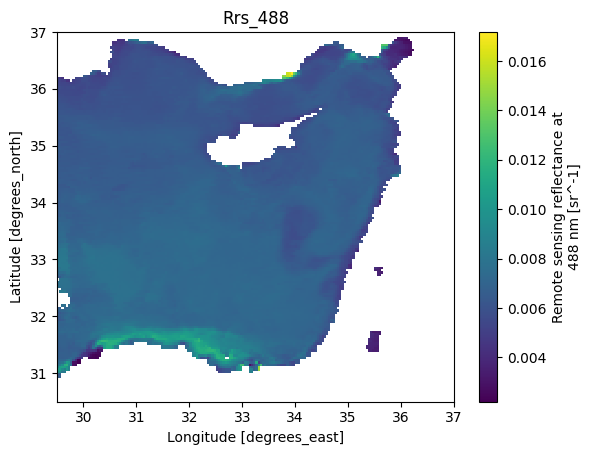

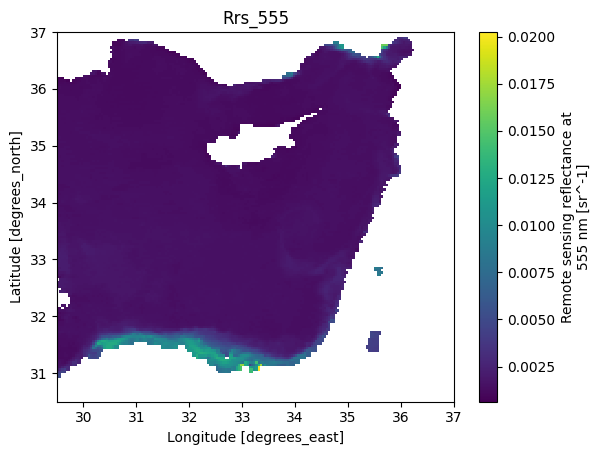

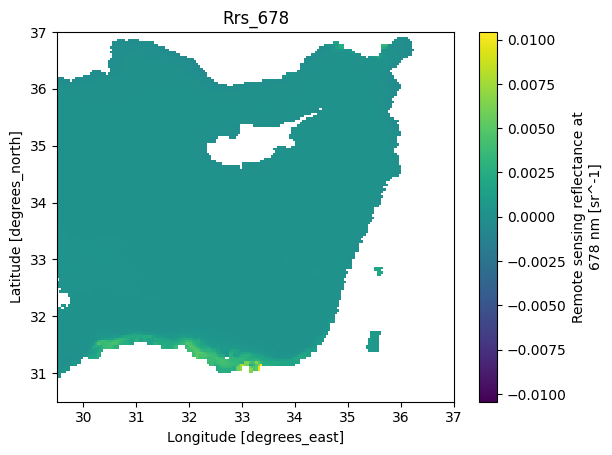

In [7]:


variables_acronym = ['CHL', 'RRS', 'RRS', 'RRS', 'RRS', 'RRS']
variables = ['chlor_a', 'Rrs_412', 'Rrs_443', 'Rrs_488', 'Rrs_555', 'Rrs_678']


day_example='20090821_20090828'

for var, acr in zip(variables, variables_acronym):

    file_path = f'./data_brut/AQUA_MODIS.{day_example}.L3m.8D.{acr}.x_{var}.nc'
    ds = xr.open_dataset(file_path)
    var_name = list(ds.data_vars.keys())[0]  # usually the main variable


    data = ds[var_name]
    lon = ds['lon']
    lat = ds['lat']
    lon=np.array(lon)
    lat=np.array(lat)

    if var_name == 'chlor_a':
        np.log10(data).plot(cmap='viridis')
        plt.title(var_name)
        plt.show()

    else:


        data.plot(cmap='viridis')
        plt.title(var_name)
        plt.show()



In [8]:
lon_i=np.linspace(29.8,36.2, 128)
lat_i=np.linspace(36.86,30.5, 128)

wf = lambda r: 1/r**2


source_def = geometry.AreaDefinition('source', 'source', 'source',
                                     {'proj': 'latlong', 'lon_0': 0},
                                     len(lon), len(lat),
                                     (np.min(lon), np.min(lat), np.max(lon), np.max(lat)))

# Define the target grid
target_def = geometry.AreaDefinition('target', 'target', 'target',
                                     {'proj': 'latlong', 'lon_0': 0},
                                     len(lon_i), len(lat_i),
                                     (np.min(lon_i), np.min(lat_i), np.max(lon_i), np.max(lat_i)))
radius_of_influence = 50000

In [9]:

variables_acronym = ['CHL', 'RRS', 'RRS', 'RRS', 'RRS', 'RRS']
variables = ['chlor_a', 'Rrs_412', 'Rrs_443', 'Rrs_488', 'Rrs_555', 'Rrs_678']

destination_path = './merged_filtered_data'
os.makedirs(destination_path, exist_ok=True)

with open('cloudless_list.txt', 'r') as f:
    filenames = f.read().splitlines()

nbr_of_days = 0

for days in filenames:

    rs_all = []

    for var, acr in zip(variables, variables_acronym):

        filepath = f'./data_brut/AQUA_MODIS.{days}.L3m.8D.{acr}.x_{var}.nc'

        ds = nc.Dataset(filepath, "r")

        lon_chl = ds['lon'][:]
        lat_chl = ds['lat'][:]

        source_def_chl = geometry.AreaDefinition(
            'source', 'source', 'source',
            {'proj': 'latlong', 'lon_0': 0},
            len(lon_chl), len(lat_chl),
            (np.min(lon_chl), np.min(lat_chl), np.max(lon_chl), np.max(lat_chl))
        )

        rs = ds[var][:]
        rs = np.array(rs)

        rs[rs < -900] = np.nan
        #rs[rs <= 0] = np.nan

        rs_interp = pyresample.kd_tree.resample_custom(
            source_def_chl, rs, target_def,
            radius_of_influence=500000,
            neighbours=10,
            weight_funcs=wf,
            fill_value=None
        )

        rs_normalized = normalize_with_nan(rs_interp)



        rs_all.append(rs_normalized)

        ds.close()

    rs_all = np.array(rs_all)
    rs_all = np.flip(rs_all, axis=1)

    new_filename = f"{destination_path}/{days}.nc"

    nc_file = nc.Dataset(new_filename, 'w', format='NETCDF4')

    nc_file.createDimension('lon', len(lon_i))
    nc_file.createDimension('lat', len(lat_i))
    nc_file.createDimension('time', rs_all.shape[0])

    lon_var = nc_file.createVariable('lon', np.float64, ('lon',))
    lat_var = nc_file.createVariable('lat', np.float64, ('lat',))
    rs_all_var = nc_file.createVariable('rs_all', rs_all.dtype, ('time', 'lat', 'lon'))

    lon_var[:] = lon_i[:]
    lat_var[:] = lat_i[:]
    rs_all_var[:] = rs_all

    nc_file.close()

    print(f"Saved NetCDF file: {new_filename}")

    nbr_of_days += 1

/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261

Saved NetCDF file: ./merged_filtered_data/20030109_20030116.nc


/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,


Saved NetCDF file: ./merged_filtered_data/20030125_20030201.nc


/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261

...

/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,


Saved NetCDF file: ./merged_filtered_data/20221211_20221218.nc


/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,


Saved NetCDF file: ./merged_filtered_data/20221219_20221226.nc


/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,
/usr/local/lib/python3.12/dist-packages/pyresample/kd_tree.py:261: UserWarning: Possible more than 10 neighbours within 500000 m for some data points
  get_neighbour_info(source_geo_def,


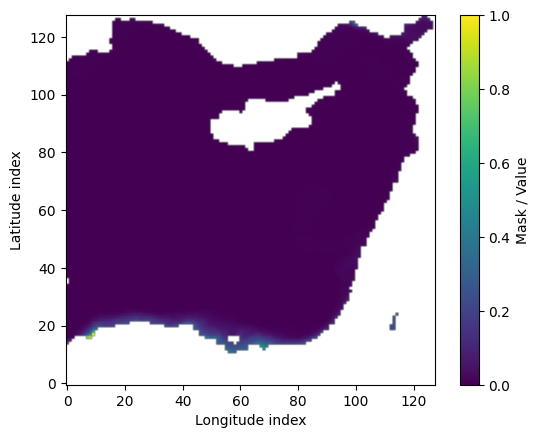

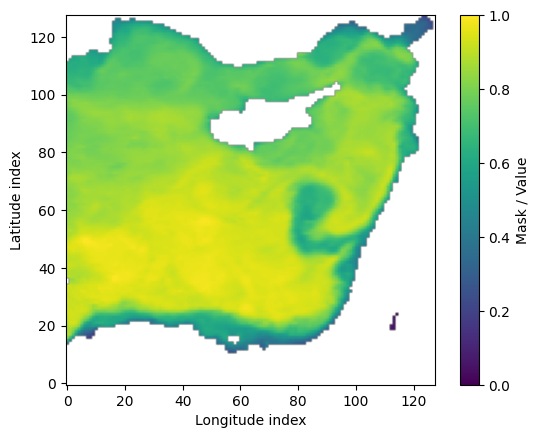

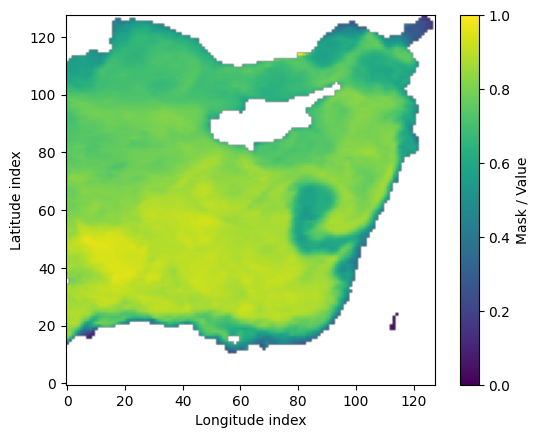

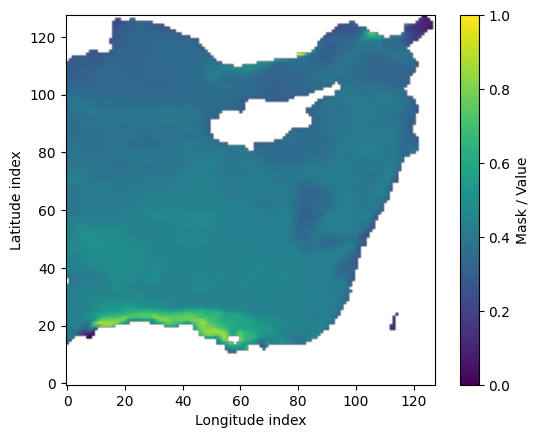

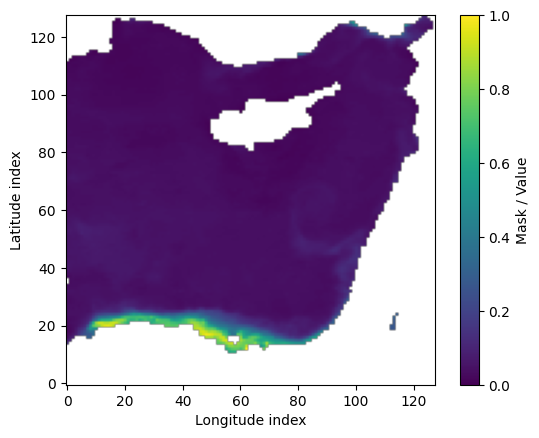

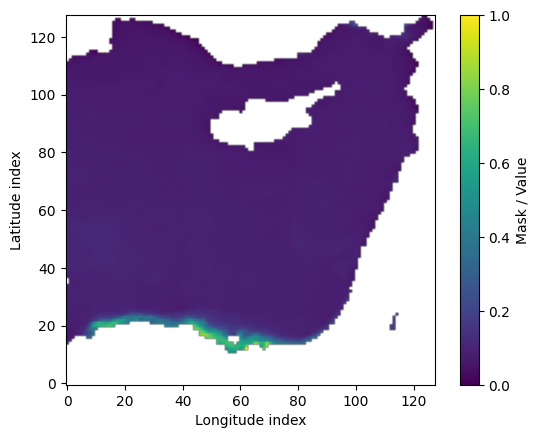

In [10]:
### To compare with the first plots

filepath= './merged_filtered_data/20090821_20090828.nc'
ds = nc.Dataset(filepath, 'r')

# Read variables
rs_all = ds['rs_all'][:]   # shape: (time, lat, lon)
lon = ds['lon'][:]
lat = ds['lat'][:]

ds.close()

for t in range(0, rs_all.shape[0]):

    data = rs_all[t]

# Plot
    plt.figure()
    plt.imshow(data, origin='lower')

    plt.colorbar(label='Mask / Value')
    plt.xlabel("Longitude index")
    plt.ylabel("Latitude index")
    plt.show()

In [11]:
# The folder "merged_filtered_data" contains more than 700 NetCDF files.
# However, not all samples are labeled, since labeling is time-consuming.
# Therefore, we only load the files that are listed in "labeled_days_list.txt",which contains the subset of files with available labels.

file_id = "172QBBKHYUnp-Z-NtG7EWoAb8lYZno62_"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, output="labeled_days_list.txt", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=172QBBKHYUnp-Z-NtG7EWoAb8lYZno62_
To: /content/labeled_days_list.txt
100%|██████████| 2.59k/2.59k [00:00<00:00, 5.87MB/s]


'labeled_days_list.txt'

In [12]:
input_dir = "./merged_filtered_data/"
label_dir = "./labeled/"


with open("labeled_days_list.txt", "r") as f:
    labeled_dates = set(line.strip() for line in f) # Keep only .nc files that are labeled


file_list_labeled = [
    f for f in sorted(os.listdir(input_dir))
    if f.endswith(".nc") and f[:-3] in labeled_dates
]


file_list_labeled = [
    f for f in file_list_labeled
    if os.path.exists(os.path.join(label_dir, f))
]

print(f"Number of labeled samples: {len(file_list_labeled)}")

# Dataset + DataLoader
dataset = NetCDFDataset(input_dir, label_dir, file_list_labeled)

loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2  # optional (faster loading)
)

Number of labeled samples: 139


In [13]:
x, y = next(iter(loader))
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: torch.Size([1, 6, 128, 128])
y shape: torch.Size([1, 128, 128])


In [ ]:
# If you think the dataset is insufficient for training, consider methods to augment or expand it using the data you already have